# 01 - Linear Regression & the Normal Equation

Part of Classical ML — Linear Models. First topic of the chapter: derive OLS from its objective function, solve it two ways (closed-form and gradient descent), verify both against `sklearn` and against each other, and understand the geometry (projection) and failure mode (multicollinearity) that motivate the next topic, Ridge/Lasso.

**Book references:** MML §9.1-9.2 (Linear Regression, pp.303-313); ESL §3.1-3.2 for the classical statistical treatment.

# Part A - The Objective Function and Its Closed-Form Solution

Model: `y = Xβ + ε`. Objective: minimize the residual sum of squares `RSS(β) = ||y - Xβ||²`.

**Deriving the normal equation** (this is exactly Advanced Optimization notebook 01's quadratic-form gradient identity, applied): expand `RSS(β) = (y-Xβ)ᵀ(y-Xβ)`, take the gradient with respect to `β`, and set it to zero:

```
∇β RSS(β) = -2Xᵀ(y - Xβ) = 0
       XᵀXβ = Xᵀy
          β = (XᵀX)⁻¹ Xᵀy       (the normal equation)
```

This requires `XᵀX` to be invertible — Part D shows exactly what happens when it isn't.

In [8]:
import numpy as np

rng = np.random.default_rng(0)
n, p = 200, 3
X = rng.normal(size=(n, p))
true_beta = np.array([2.0, -1.5, 0.5])
y = X @ true_beta + 1.0 + rng.normal(scale=0.5, size=n)   # true intercept = 1.0

X_design = np.hstack([np.ones((n, 1)), X])                 # prepend a column of 1s for the intercept
beta_normal_eq = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
print("normal equation (intercept, b1, b2, b3):", beta_normal_eq)
print("true values were:                        [1.0, 2.0, -1.5, 0.5]")

normal equation (intercept, b1, b2, b3): [ 0.98193058  1.95500869 -1.5480763   0.52651279]
true values were:                        [1.0, 2.0, -1.5, 0.5]


In [9]:
!pip3 install scikit-learn

In [10]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(X, y)
sk_beta = np.r_[sk.intercept_, sk.coef_]
print("sklearn (intercept, b1, b2, b3):        ", sk_beta)
print("matches our normal equation exactly:", np.allclose(beta_normal_eq, sk_beta, atol=1e-8))

sklearn (intercept, b1, b2, b3):         [ 0.98193058  1.95500869 -1.5480763   0.52651279]
matches our normal equation exactly: True


# Part B - Gradient Descent: the Iterative Alternative

The normal equation costs `O(p³)` to invert a `p×p` matrix — fine for a handful of features, prohibitive for very large `p`. Gradient descent (Calculus notebook 03) reaches the same optimum iteratively, at `O(np)` per step, no matrix inversion required.

In [11]:
def gd_linreg(X, y, lr=0.1, steps=1000):
    beta = np.zeros(X.shape[1])
    n = len(y)
    history = []
    for _ in range(steps):
        residual = X @ beta - y
        grad = (2 / n) * X.T @ residual
        beta -= lr * grad
        history.append(np.mean(residual**2))
    return beta, history

# standardize columns for stable step sizes (standard practice) -- keep the intercept column constant
Xs = (X_design - X_design.mean(0)) / (X_design.std(0) + 1e-12)
Xs[:, 0] = 1.0

beta_gd, history = gd_linreg(Xs, y)
beta_ne_std = np.linalg.inv(Xs.T @ Xs) @ Xs.T @ y

print("gradient descent beta:", beta_gd)
print("normal equation beta (same standardized space):", beta_ne_std)
print("agree to 1e-3:", np.allclose(beta_gd, beta_ne_std, atol=1e-3))

gradient descent beta: [ 0.77268816  1.98186582 -1.54572943  0.51324101]
normal equation beta (same standardized space): [ 0.77268816  1.98186582 -1.54572943  0.51324101]
agree to 1e-3: True


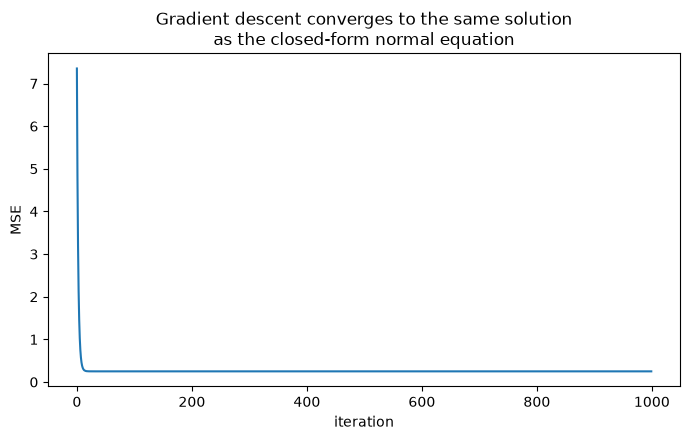

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history)
ax.set_xlabel("iteration"); ax.set_ylabel("MSE")
ax.set_title("Gradient descent converges to the same solution\nas the closed-form normal equation")
fig.tight_layout()
fig.savefig(FIG_DIR / "gd_convergence.png", dpi=140)
plt.show()

# Part C - The Geometry: OLS Is a Projection

`ŷ = Xβ̂` is literally the **orthogonal projection** of `y` onto the column space of `X` (Linear Algebra notebook 02's projection formula, `P = X(XᵀX)⁻¹Xᵀ`, applied here to regression). The defining property of any orthogonal projection: the residual `y - ŷ` is orthogonal to everything in the space being projected onto — i.e. `Xᵀ(y - ŷ) = 0`. This is not a separate fact to memorize; it is exactly the normal equation rearranged, and it should hold to numerical precision for any least-squares fit.

In [13]:
X2 = rng.normal(size=(30, 2))                         # a smaller 2-predictor example
beta2 = np.array([1.5, -1.0])
y2 = X2 @ beta2 + rng.normal(scale=1.2, size=30)        # noisy -- y2 is NOT exactly in col(X2)

beta2_hat = np.linalg.inv(X2.T @ X2) @ X2.T @ y2
y2_hat = X2 @ beta2_hat                                   # the projection of y2 onto col(X2)
residual2 = y2 - y2_hat

print("X^T @ residual (should be ~0, the defining property of a projection):")
print(X2.T @ residual2)
print("orthogonal to machine precision:", np.allclose(X2.T @ residual2, 0, atol=1e-8))

X^T @ residual (should be ~0, the defining property of a projection):
[-5.55111512e-16 -2.44249065e-15]
orthogonal to machine precision: True


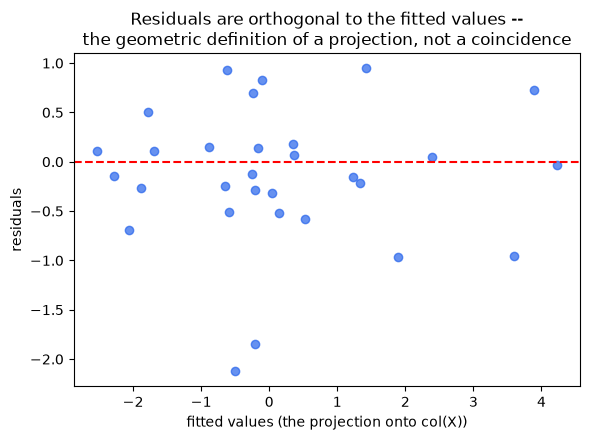

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(y2_hat, residual2, alpha=0.7, color="#2563eb")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("fitted values (the projection onto col(X))")
ax.set_ylabel("residuals")
ax.set_title("Residuals are orthogonal to the fitted values --\nthe geometric definition of a projection, not a coincidence")
fig.tight_layout()
fig.savefig(FIG_DIR / "projection_and_multicollinearity.png", dpi=140)
plt.show()

# Part D - When the Normal Equation Breaks: Multicollinearity

`(XᵀX)⁻¹` requires `XᵀX` to be invertible, which fails (or nearly fails) when predictor columns are linearly dependent, or close to it — two nearly-duplicate features being the simplest example. The **condition number** of `XᵀX` measures exactly how close to singular it is; a large condition number means small changes in the data produce huge changes in the estimated coefficients, and matrix inversion becomes numerically unstable even when technically still invertible.

In [15]:
X_bad = np.column_stack([X2, X2[:, 0]*0.999 + rng.normal(scale=0.001, size=30)])   # near-duplicate 3rd column

cond_good = np.linalg.cond(X2.T @ X2)
cond_bad = np.linalg.cond(X_bad.T @ X_bad)
print(f"condition number, 2 independent predictors:        {cond_good:.2f}")
print(f"condition number, 3rd predictor ~ duplicate of 1st: {cond_bad:,.0f}")
print(f"that's a {cond_bad/cond_good:,.0f}x increase -- from adding ONE near-redundant column")

condition number, 2 independent predictors:        1.72
condition number, 3rd predictor ~ duplicate of 1st: 3,217,130
that's a 1,873,017x increase -- from adding ONE near-redundant column


This instability — not just "the math technically still works" but "the *numerics* stop being trustworthy" — is exactly what motivates the next topic. Adding a small penalty `λI` to `XᵀX` before inverting (`(XᵀX + λI)⁻¹`) fixes the singularity directly: this is Ridge Regression, and it is not a heuristic patch, it is a principled solution derived from a Bayesian prior on the coefficients — covered next.

## Self-check before moving on

- [ ] I can derive the normal equation from the RSS objective via its gradient, from memory
- [ ] I can explain why OLS is a projection, and why residuals are orthogonal to the fitted values as a direct consequence
- [ ] I can state the complexity tradeoff between the normal equation (O(p³)) and gradient descent (O(np) per step)
- [ ] I can explain, precisely, what multicollinearity does to `XᵀX`'s condition number and why that matters numerically, not just theoretically
- [ ] I can state linear regression's core assumptions (linearity, homoscedasticity, no multicollinearity, independence) and recognize when each is violated

Next: `02-ridge-lasso-elastic-net.ipynb`